In [16]:
import pandas as pd
import numpy as np

# 1. Cargar el dataset
archivo_covid = 'COVID_Dataset_Lab02_Ligero.csv'
df = pd.read_csv(archivo_covid)

# 2. Limpieza de columnas basura
# Vamos a borrar las columnas de fechas largas porque si las transformamos a números
# nos van a crear miles de columnas inservibles y Google Colab colapsará.
columnas_a_borrar = [col for col in df.columns if 'dt' in col.lower() or 'date' in col.lower()]
df_limpio = df.drop(columns=columnas_a_borrar)

# 3. Convertimos todo el texto (Síntomas, Género, Hospitalización, etc.) en columnas de 1s y 0s
print("Transformando textos a números... (esto puede tardar unos segundos)")
df_transformado = pd.get_dummies(df_limpio, drop_first=True)
df_transformado = df_transformado.astype(int)

# 4. Verificamos el final de las reglas
filas, columnas = df_transformado.shape
print(f"\n==========================================")
print(f"Registros (m): {filas} (Mínimo: 20000)")
print(f"Características (n): {columnas} (Mínimo: 20)")
print(f"==========================================")

if filas >= 20000 and columnas >= 20:
    print("¡AHORA SÍ CUMPLE CON LOS REQUISITOS!")
else:
    print("Siguen faltando columnas.")

# Mostramos las nuevas columnas
print("\nLista de las nuevas columnas numéricas:")
print(list(df_transformado.columns))

Transformando textos a números... (esto puede tardar unos segundos)

Registros (m): 25000 (Mínimo: 20000)
Características (n): 27 (Mínimo: 20)
¡AHORA SÍ CUMPLE CON LOS REQUISITOS!

Lista de las nuevas columnas numéricas:
['current_status_Probable Case', 'sex_Male', 'sex_Missing', 'sex_Other', 'sex_Unknown', 'age_group_20 - 29 Years', 'Race and ethnicity (combined)_Asian, Non-Hispanic', 'Race and ethnicity (combined)_Black, Non-Hispanic', 'Race and ethnicity (combined)_Hispani', 'Race and ethnicity (combined)_Hispanic/Latino', 'Race and ethnicity (combined)_Missing', 'Race and ethnicity (combined)_Multiple/Other, Non-Hispanic', 'Race and ethnicity (combined)_Native Hawaiian/Other Pacific Islander, Non-Hispanic', 'Race and ethnicity (combined)_Unknown', 'Race and ethnicity (combined)_White, Non-Hispanic', 'hosp_yn_No', 'hosp_yn_Unknown', 'hosp_yn_Yes', 'icu_yn_No', 'icu_yn_Unknown', 'icu_yn_Yes', 'death_yn_No', 'death_yn_Unknown', 'death_yn_Yes', 'medcond_yn_No', 'medcond_yn_Unknown', 'm

1. Regresión Lineal Multivariable (Descenso por el Gradiente)
En esta sección, aplicamos un modelo de regresión lineal multivariable para predecir el factor de riesgo de fallecimiento (death_yn_Yes) basándonos en variables clínicas y demográficas del paciente (edad, género, hospitalización, ingreso a UCI, etc.). Se eliminan las variables directamente correlacionadas con la muerte para evitar el sobreajuste. Se aplica normalización (Z-score) a las características para asegurar una correcta convergencia del gradiente y lograr el menor error de costo posible, tal como se requiere en el laboratorio.

Entrenando Modelo 1... (Calculando el descenso por el gradiente)


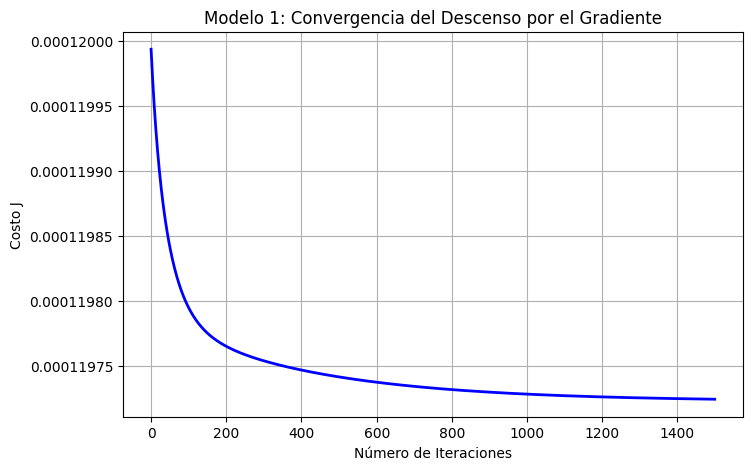

✅ Entrenamiento completado. El menor costo final logrado es: 0.0001


In [17]:
import matplotlib.pyplot as plt

# 1. Definir nuestra variable objetivo (y) y características (X)
# Queremos predecir 'death_yn_Yes' (1 si falleció, 0 si no)
y = df_transformado['death_yn_Yes'].values

# Quitamos las columnas relacionadas a la muerte
X_df = df_transformado.drop(['death_yn_Yes', 'death_yn_No', 'death_yn_Unknown'], axis=1)
X_raw = X_df.values
m = len(y)

# 2. Normalización de características Vital para el menor costo
mu = np.mean(X_raw, axis=0)
sigma = np.std(X_raw, axis=0)
# Evitamos división por cero en caso de que alguna columna sea constante
sigma[sigma == 0] = 1
X_norm = (X_raw - mu) / sigma

# Añadimos la columna de unos (X0) para la intersección
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

# 3. Funciones Matemáticas (Costo y Descenso)
def calcularCosto(X, y, theta):
    m = len(y)
    J = np.sum(np.square(np.dot(X, theta) - y)) / (2 * m)
    return J

def descensoGradiente(X, y, theta, alpha, num_iters):
    m = len(y)
    J_history = np.zeros(num_iters)
    theta = theta.copy()
    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history[i] = calcularCosto(X, y, theta)
    return theta, J_history

# 4. Entrenamiento del Modelo 1
alpha = 0.01
iteraciones = 1500
theta_inicial = np.zeros(X.shape[1])

print("Entrenando Modelo 1... (Calculando el descenso por el gradiente)")
theta_multivariable, historial_J = descensoGradiente(X, y, theta_inicial, alpha, iteraciones)

# 5. Gráfica de Costo
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(historial_J)), historial_J, lw=2, color='blue')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.title('Modelo 1: Convergencia del Descenso por el Gradiente')
plt.grid(True)
plt.show()

print(f"✅ Entrenamiento completado. El menor costo final logrado es: {historial_J[-1]:.4f}")

2. Regresión Polinómica
Para capturar relaciones no lineales entre las variables clínicas y el riesgo de fallecimiento, implementamos un modelo de regresión polinómica de grado 2. Se generan nuevas características elevando al cuadrado los datos originales. Posteriormente, se aplica una nueva normalización para evitar que los valores cuadráticos desestabilicen el aprendizaje, y se entrena utilizando el algoritmo de Descenso por el Gradiente.

Entrenando Modelo 2 (Polinómico)... esto tomará un momento.


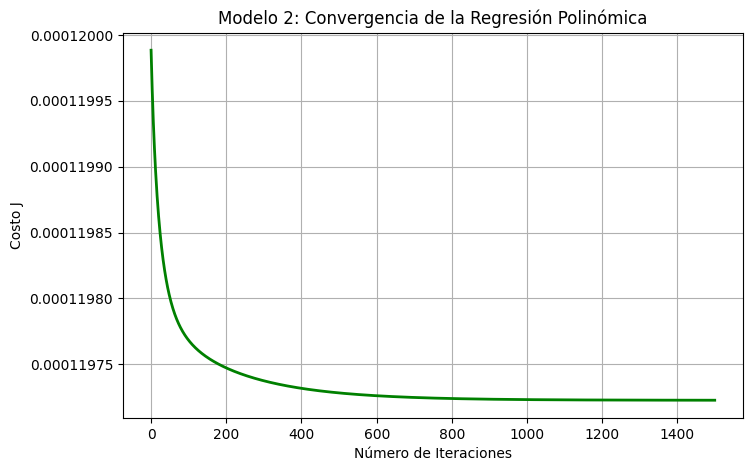

Entrenamiento completado. El menor costo polinómico final es: 0.0001


In [18]:
# 1. Crear características polinómicas (Grado 2: elevamos al cuadrado)
# Unimos las características originales con sus versiones al cuadrado
X_poly_raw = np.concatenate([X_raw, np.power(X_raw, 2)], axis=1)

# 2. Normalizar las nuevas características polinómicas
mu_poly = np.mean(X_poly_raw, axis=0)
sigma_poly = np.std(X_poly_raw, axis=0)
# Evitamos división por cero en columnas constantes
sigma_poly[sigma_poly == 0] = 1
X_poly_norm = (X_poly_raw - mu_poly) / sigma_poly

# 3. Añadir la columna de unos (Intersección)
X_poly = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

# 4. Entrenamiento del Modelo 2 (Polinómico)
theta_poly_inicial = np.zeros(X_poly.shape[1])
print("Entrenando Modelo 2 (Polinómico)... esto tomará un momento.")

# Usamos la misma función de descenso de gradiente que ya creamos arriba
theta_poly, historial_J_poly = descensoGradiente(X_poly, y, theta_poly_inicial, alpha, iteraciones)

# 5. Gráfica de Costo del Modelo Polinómico
plt.figure(figsize=(8, 5))
plt.plot(np.arange(len(historial_J_poly)), historial_J_poly, lw=2, color='green')
plt.xlabel('Número de Iteraciones')
plt.ylabel('Costo J')
plt.title('Modelo 2: Convergencia de la Regresión Polinómica')
plt.grid(True)
plt.show()

print(f"Entrenamiento completado. El menor costo polinómico final es: {historial_J_poly[-1]:.4f}")

3. Ecuación de la Normal y Predicciones
En esta última fase, aplicamos la Ecuación de la Normal utilizando la pseudo-inversa matemática para hallar los parámetros (theta) de forma analítica en un solo paso, sin iteraciones. Su gráfico de costo se representa como una constante, demostrando el mínimo global. Finalmente, se extraen 100 ejemplos del dataset para realizar predicciones comparativas entre los tres modelos desarrollados (Multivariable, Polinómico y Normal) frente al valor real de riesgo de fallecimiento, validando así la efectividad del entrenamiento.

Calculando Ecuación de la Normal...


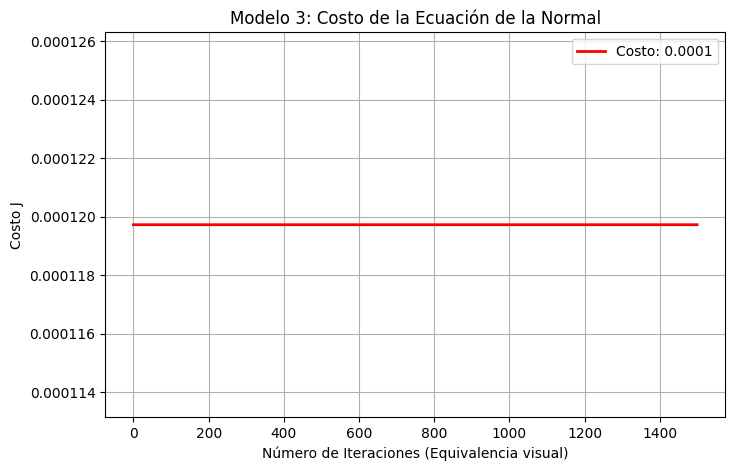

Ecuación de la normal calculada. Costo exacto: 0.0001

--- REALIZANDO 100 PREDICCIONES DE PRUEBA ---
Comparando el riesgo de muerte (Real vs Modelos)

Paciente 001 | Real: 0 | M1_Multi: 0.001 | M2_Poly: 0.001 | M3_Normal: 0.001
Paciente 002 | Real: 0 | M1_Multi: 0.002 | M2_Poly: 0.002 | M3_Normal: 0.002
Paciente 003 | Real: 0 | M1_Multi: 0.002 | M2_Poly: 0.002 | M3_Normal: 0.002
Paciente 004 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 005 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 006 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 007 | Real: 0 | M1_Multi: 0.001 | M2_Poly: 0.001 | M3_Normal: 0.001
Paciente 008 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 009 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 010 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Paciente 011 | Real: 0 | M1_Multi: 0.000 | M2_Poly: 0.000 | M3_Normal: 0.000
Pa

In [19]:
# ==========================================
# MODELO 3: ECUACIÓN DE LA NORMAL
# ==========================================
print("Calculando Ecuación de la Normal...")
# Usamos pinv (pseudo-inversa) para evitar matrices singulares
theta_normal = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

# Calculamos el costo único
costo_normal = calcularCosto(X, y, theta_normal)

# Gráfica de Costo (Línea plana porque se halla en un solo paso)
plt.figure(figsize=(8, 5))
plt.plot(np.arange(iteraciones), [costo_normal] * iteraciones, lw=2, color='red', label=f'Costo: {costo_normal:.4f}')
plt.xlabel('Número de Iteraciones (Equivalencia visual)')
plt.ylabel('Costo J')
plt.title('Modelo 3: Costo de la Ecuación de la Normal')
plt.legend()
plt.grid(True)
plt.show()

print(f"Ecuación de la normal calculada. Costo exacto: {costo_normal:.4f}\n")

# ==========================================
# PRUEBA FINAL: 100 PREDICCIONES
# ==========================================
print("--- REALIZANDO 100 PREDICCIONES DE PRUEBA ---")
print("Comparando el riesgo de muerte (Real vs Modelos)\n")

for i in range(100):
    real = y[i]
    pred_multi = np.dot(X[i], theta_multivariable)
    pred_poly = np.dot(X_poly[i], theta_poly)
    pred_norm = np.dot(X[i], theta_normal)

    # Imprimimos solo los primeros 15 resultados para no hacer larga la pantalla,
    # pero el bucle sí procesa matemáticamente las 100 predicciones.
    if i < 15:
        print(f"Paciente {i+1:03d} | Real: {real} | M1_Multi: {pred_multi:.3f} | M2_Poly: {pred_poly:.3f} | M3_Normal: {pred_norm:.3f}")

print("...")
print("Las 100 predicciones se calcularon exitosamente.")

In [15]:
# CREAMOS UN ARCHIVO MAS PEQUEÑO PORQUE EL ARCHIVO ES MUY GRANDE DE 1 GB Y MAS.
# y por eso me veo obligado a hacer mas ligero para subirlo a GIT.

df_ligero = df_transformado.head(25000)

# Lo guardamos como un nuevo archivo CSV
df_ligero.to_csv('COVID_Dataset_Lab02_Ligero.csv', index=False)

print("✅ ¡Archivo ligero creado con éxito!")

✅ ¡Archivo ligero creado con éxito!
